# Assignment 1 - Option A

### Part 1

The following code is the result of editing a program originally written by OpenAI ChatGPT (GPT-5 Thinking mini). The first prompt given was the assignment brief from section 1: Problem to section 2.1: Code inclusive, with no extra instructions. The lines I have written are indicated by comments. Everything else is AI-generated.

The second prompt was given to Google Gemini. The entirety of the ChatGPT-generated code was pasted into a prompt along with instructions:  
"What does this plot do and what units does each quantity have. Please change the plotting axis labels appropriately."  
  
Gemini then asked "Would you like to expand this solver to calculate the probability density ($|\psi|^2$) to visualize where the particle is most likely to be found, rather than just the amplitude?", and the prompt "yes please" was given. The code generated as a result plotted eigenfunctions for 4 energy levels, not 10. This was fixed with the prompt "I want it to plot 10 eigenfunctiomns, not 4". The returned code was copied into this notebook.

Debugging ensued: The code was run and pasted back into Gemini with the additional prompt "Why is this saying x_max is not defined?".  
This process was repeated with the new prompt "The graph outputted cuts off the bottom of the ground state line." The axis limits for the first graph were changed as a result.  
  
The next prompt used was "How can I also make the code output each eigenfunction individually, and also plot the probability functions?", then "Can you change this code to give axis labels to each subplot instead of the total thing? Also I want the first 11 eigenfunctions instead of 10. Please also explain to me if eigenfunctions are the same as the wavefunctions."  

Before moving onto the second part of the problem, the entire code so far was pasted in Gemini along with the PDF task description, along with the prompt "so does this code satisfy task 1 from this assignment description?". The response was not used to change the code, as AI deemed it suitable for satisfying the task description.

n=0, numeric E=0.999984, analytic E=1.000000, absolute error=1.603231e-05
n=1, numeric E=2.999920, analytic E=3.000000, absolute error=8.016255e-05
n=2, numeric E=4.999792, analytic E=5.000000, absolute error=2.084256e-04
n=3, numeric E=6.999599, analytic E=7.000000, absolute error=4.008246e-04
n=4, numeric E=8.999343, analytic E=9.000000, absolute error=6.573626e-04
n=5, numeric E=10.999022, analytic E=11.000000, absolute error=9.780426e-04
n=6, numeric E=12.998637, analytic E=13.000000, absolute error=1.362868e-03
n=7, numeric E=14.998188, analytic E=15.000000, absolute error=1.811841e-03
n=8, numeric E=16.997675, analytic E=17.000000, absolute error=2.324966e-03
n=9, numeric E=18.997098, analytic E=19.000000, absolute error=2.902245e-03


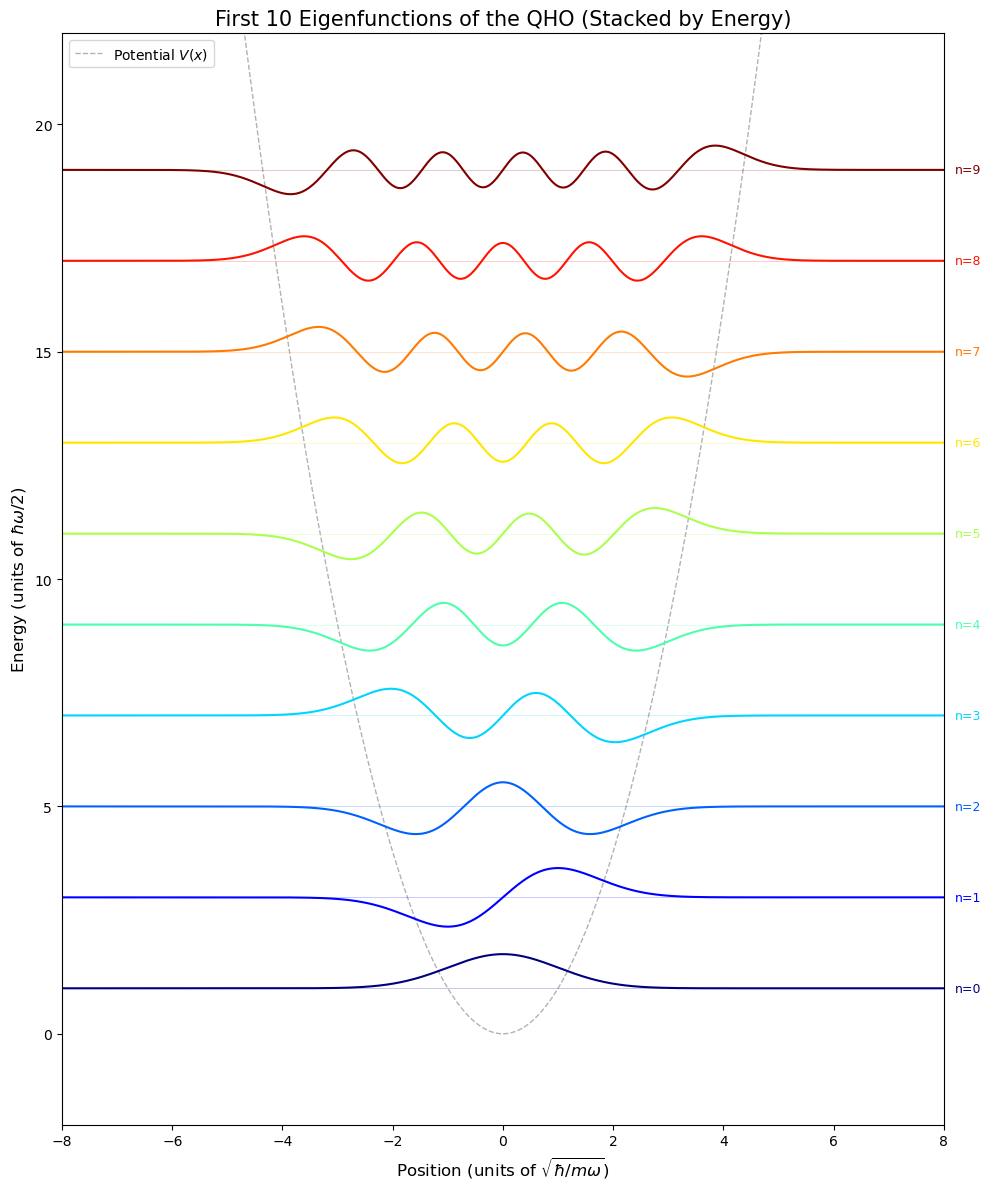

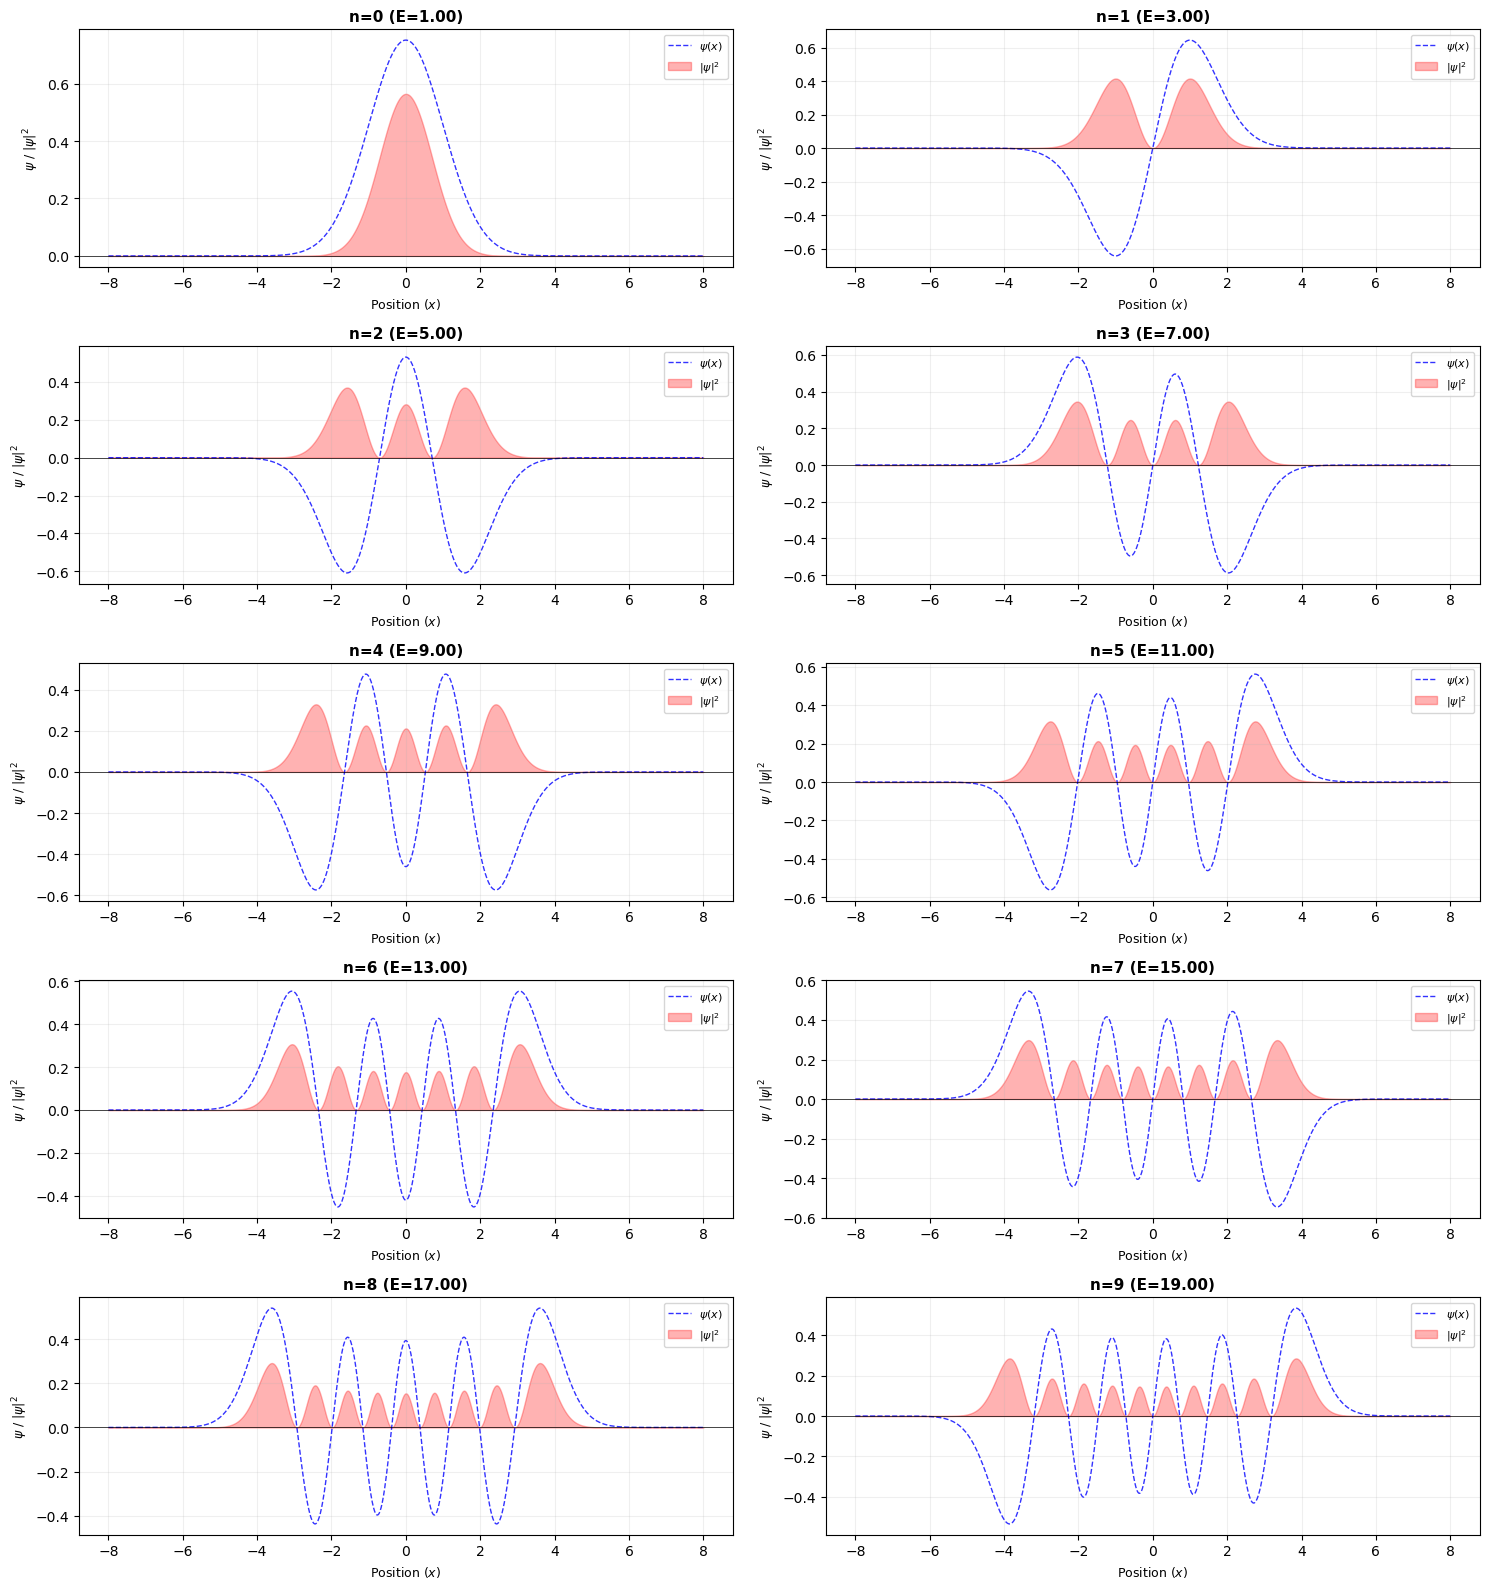

In [1]:
# Import libraries, produced by Gemini
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy.linalg import eigh
import matplotlib.cm as cm
import matplotlib.ticker as ticker

# Defining the Hamiltonian matrix, produced by Gemini
def kinetic_matrix(N, dx, prefactor=-0.5):
    diag = np.full(N, -2.0) / (dx**2)
    off = np.full(N-1, 1.0) / (dx**2)
    H = np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)
    return prefactor * H

# -------------------
# Harmonic oscillator
# -------------------

# Defining a function to solve the harmonic oscillator, produced by Gemini
def solve_harmonic_oscillator(x_min, x_max, N, n_eig):
    x = np.linspace(x_min, x_max, N)
    dx = (x_max - x_min)/(N-1) # My code: alternative way of calculating dx.
    V = x**2 # My code: Changed from 1/2 * x**2 because ChatGPT misinterpreted the prompt given to it.
    T = kinetic_matrix(N, dx, prefactor=-1.0) # My code: Changed prefactor from -0.5 for same reason.
    H = T + np.diag(V)
    energies, vecs = eigh(H)
    norms = np.sqrt(np.sum(np.abs(vecs)**2, axis=0) * dx)
    vecs_normed = vecs / norms
    
    return x, dx, energies[:n_eig], vecs_normed[:, :n_eig]


# Define parameters, produced by Gemini
x_min = -8.0
x_max = 8.0
n_points = 1000

num_levels = 10 # My code: each instance of num_levels was inputted manually for ease of simulating different numbers of energy levels.

# My code: initialising the variables to be used in the QHO solver.
x, dx, eigs_ho, vecs_ho = solve_harmonic_oscillator(
    x_min = x_min,
    x_max = x_max, 
    N = n_points,
    n_eig = num_levels
)

# Printing a table for comparison of calculated and expected energies, produced by Gemini
for n, E in enumerate(eigs_ho[:num_levels]):
    
    analytic_E = 2*n+1 # My code: ChatGPT did not pick up the analytic method from the assignment brief.
    
    print(f"n={n}, numeric E={E:.6f}, analytic E={analytic_E:.6f}, absolute error={abs(E - analytic_E):.6e}") 
    # ^My code: changed from a line giving incorrect errors


# Plot eigenfunctions, produced by Gemini
plt.figure(figsize=(10, 12)) # Taller figure to fit 10 levels

# Plot the Analytic Potential V(x) = x^2 for reference, produced by Gemini
plt.plot(x, x**2, color='black', linestyle='--', linewidth=1, alpha=0.3, label='Potential $V(x)$')

# Generate a color map so 10 lines look distinct, produced by Gemini
colors = cm.jet(np.linspace(0, 1, num_levels)) # My code: changing the number of colours to the variable num_levels for ease of changing this number.



# Plotting each eigenfunction solution to the QHO, separated vertically for clarity, produced by Gemini
for i in range(num_levels):
    # Offset the wavefunction by its Eigenenergy: y = E_n + psi_n
    psi_shifted = eigs_ho[i] + (vecs_ho[:, i])
    
    # Plot the wavefunction
    plt.plot(x, psi_shifted, color=colors[i], linewidth=1.5)
    
    # Add a horizontal line indicating the exact energy level E_n
    plt.axhline(eigs_ho[i], color=colors[i], linestyle='-', linewidth=0.5, alpha=0.3)
    
    # Label the state on the right side
    plt.text(x_max + 0.2, eigs_ho[i], f"n={i}", verticalalignment='center', fontsize=9, color=colors[i])

# Formatting, produced by Gemini
plt.title(f"First {num_levels} Eigenfunctions of the QHO (Stacked by Energy)", fontsize=15)
plt.xlabel(r"Position (units of $\sqrt{\hbar/m\omega}$)", fontsize=12)
plt.ylabel(r"Energy (units of $\hbar\omega/2$)", fontsize=12)

plt.xlim(x_min, x_max) # Extended x-axis slightly for labels
plt.ylim(-2, 22) # Y-axis goes up to ~20 (since E_9 = 19)

plt.legend(loc="upper left", fontsize=10) # My code

plt.tight_layout()
plt.show()


# Now plotting the probability functions of each energy level individually.

# We use a 5x2 grid (10 spots) to fit 10 plots comfortably
fig, axes = plt.subplots(5, 2, figsize=(15, 16))
axes = axes.flatten() # Convert grid to a list for easy looping, produced by Gemini

# Looping through the first 10 eigenstates, produced by Gemini
for i in range(num_levels):
    ax = axes[i]
    
    # Get data
    psi = vecs_ho[:, i]
    prob = psi**2
    
    # Plot Wavefunction (Blue Dashed)
    ax.plot(x, psi, label=r'$\psi(x)$', color='blue', linestyle='--', linewidth=1, alpha=0.8)
    
    # Plot Probability (Red Filled)
    ax.fill_between(x, prob, 0, color='red', alpha=0.3, label=r'$|\psi|^2$')
    
    # Zero line
    ax.axhline(0, color='black', linewidth=0.5)

    # Labelling
    ax.set_title(f"n={i} (E={eigs_ho[i]:.2f})", fontsize=11, fontweight='bold')
    ax.set_xlabel("Position ($x$)", fontsize=9)
    ax.set_ylabel(r"$\psi$ / $|\psi|^2$", fontsize=9)
    
    ax.grid(True, alpha=0.2)
    
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

The first graph plotted by part 1 of this code originally had axis labels "dimensionless position" and "dimensionless energy", which were changed to the current labels by the prompt "Why are the axis labels for part one of this code 'dimensionless position' and 'dimensionless energy'? What units should they be for this project? Refer to the task description attached to this prompt." given to Gemini with the assignment brief attached.  



## Part 2

The original code outputted by ChatGPT was copied into Gemini along with the prompt "I have this code for the second part of the assignment. How can i remove unnecessary code and outputs and plot the right graphs for the first 10 eigenfunctions? I also want to display numeric vs analytic eigenstates in a table." The code AI gave back was copied into this notebook and inspected, leading to this prompt being used next: "Why'd you remove calls to the QHO code? I would have thought the two parts have to have consistent calculations?" The logic given for justifying this change was read and understood.  
Next, the prompt "Why are we only in the s orbital?" was used, followed shortly by "Does the assignment description specifically say to solve for the 0 angular momentum case?" Gemini replied with "That was a choice we made to start with the simplest possible case. The assignment brief is more general. In Equation (1.11), it gives the potential as:$V(r_{i})=\frac{-2}{r_{i}}+\frac{l(l+1)}{r_{i}^{2}}$It leaves $l$ as a variable, implying that a complete solution should be able to handle any $l$ value." In light of this, the code was changed to plot radial solutions for what I thought were the 10 lowest energies, not just for $l=0$.  

After using the prompts "So can you now check that this code satisfies everything the task description requires?" and "Why is solving for l=0 implicit in the description?", I consulted Claude to cross-check that the energy plotting was right.  

In response to the attached files (part 2 of the code and the assignment brief) and prompt: "Here is some code for solving a quantum harmonic oscillator and plotting radial wavefunctions for each of the first 10 energy levels. I want you to check that the energy levels calculated here are the lowest 10 for a Hydrogen atom. You can use the pdf attached to check the relevance of this code to solving problem 2 in the assignment description.", Claude stated that the code was not plotting the right energy levels, citing the reason "The issue is that your current code doesn't respect the quantum mechanical constraint that the principal quantum number $n$ must be greater than the angular momentum quantum number $l$. This is fundamental to the hydrogen atom's structure." The proposed code returned percentage errors in the $100$s, so was swiftly removed.

--- 10 Lowest Hydrogen Eigenstates ---
Orbital  n  l Numeric E Analytic E    Error  Percentage Error
     1s  1  0 -0.999923  -1.000000 7.66e-05         -0.007659
     2p  2  1 -0.250002  -0.250000 1.60e-06         -0.000638
     2s  2  0 -0.249995  -0.250000 4.79e-06         -0.001915
     3p  3  1 -0.111112  -0.111111 7.36e-07         -0.000662
     3d  3  2 -0.111111  -0.111111 6.30e-08         -0.000057
     3s  3  0 -0.111110  -0.111111 9.46e-07         -0.000851
     4p  4  1 -0.062500  -0.062500 3.07e-07         -0.000490
     4d  4  2 -0.062500  -0.062500 2.84e-08         -0.000045
     4f  4  3 -0.062500  -0.062500 1.89e-09         -0.000003
     4s  4  0 -0.062500  -0.062500 4.05e-07         -0.000648


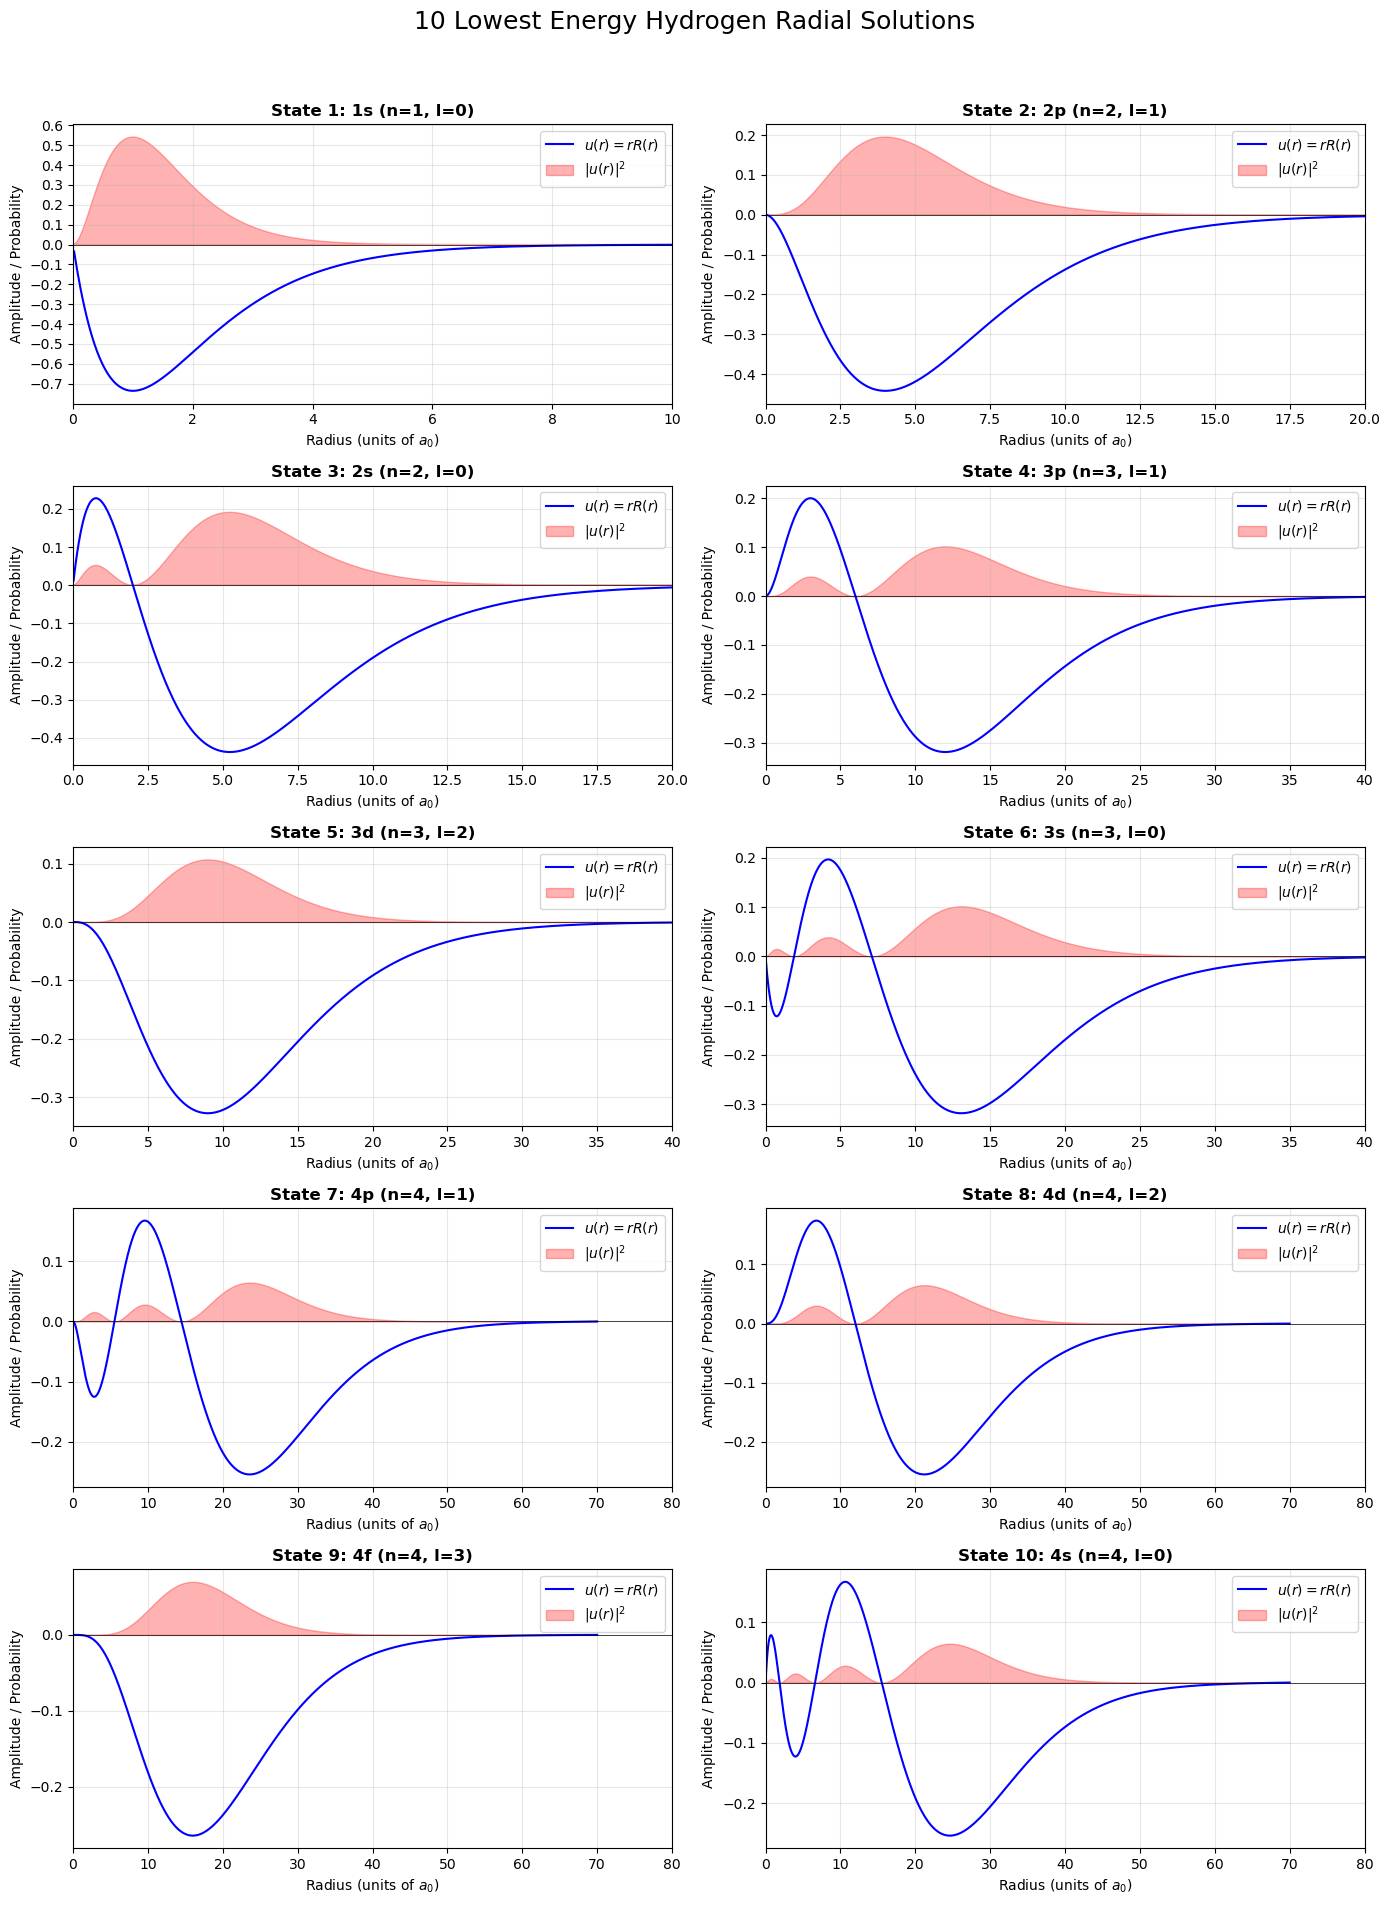

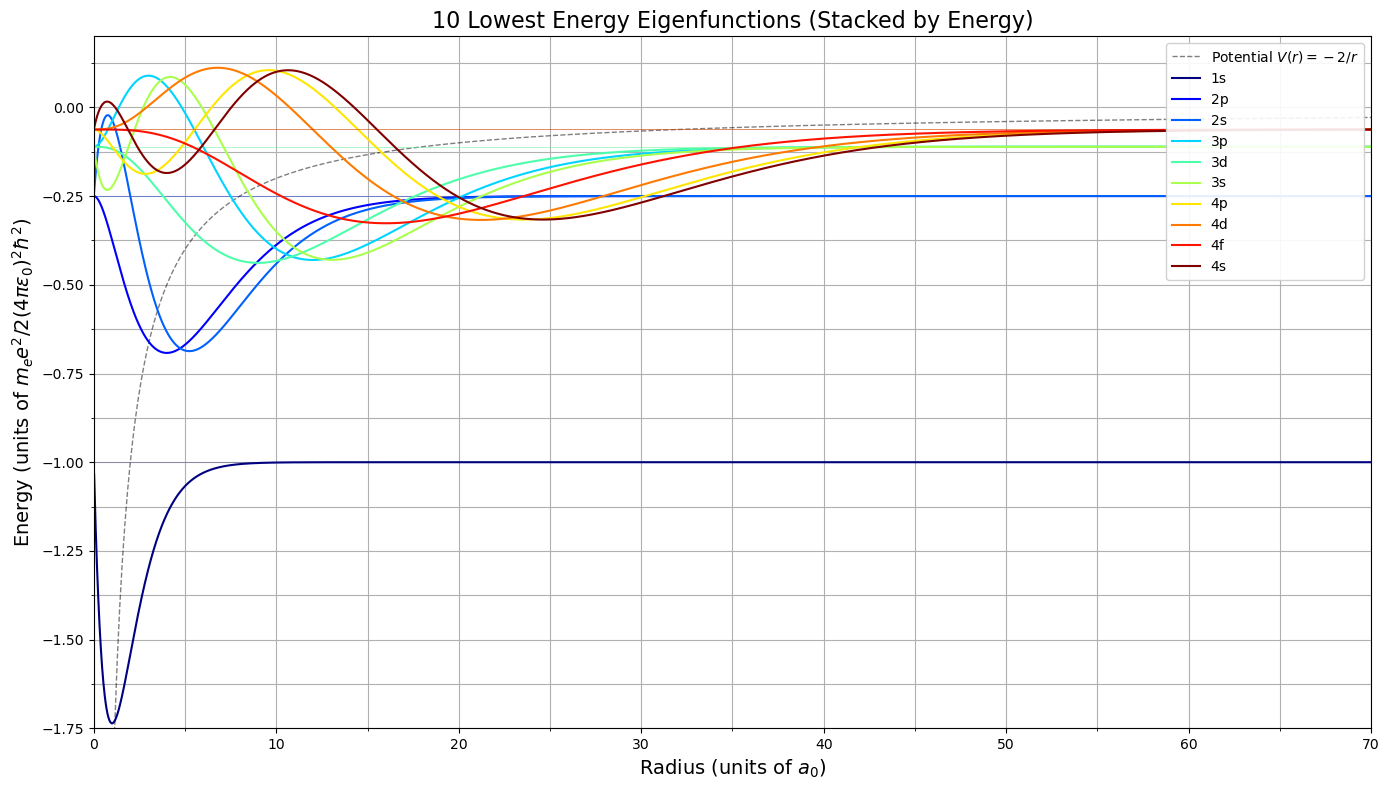

In [3]:
# Importing libraries again so each cell can be run individually, produced by Gemini
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy.linalg import eigh
import matplotlib.cm as cm
import matplotlib.ticker as ticker


def kinetic_matrix(N, dx, prefactor=-0.5):
    """
    Creates the kinetic energy matrix (2nd derivative)
    using a 3-point finite difference stencil.
    i.e. the same Hamiltonian as in part 1, produced by Gemini.
    """
    diag = np.full(N, -2.0) / (dx**2)
    off = np.full(N-1, 1.0) / (dx**2)
    H = np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)
    return prefactor * H


def solve_hydrogen_radial(r_max, N, l, n_eig):
    """
    Solves the radial Schrodinger equation for Hydrogen.
    The function u(r) = r*R(r) is solved, where R(r) is the radial wavefunction.
    The grid excludes r=0, which implicitly imposes the u(0)=0 boundary condition.
    
    Produced by Gemini.
    """
    # Build grid starting from a tiny bit > 0 to avoid division by zero. Bit size is dependent on grid resolution.
    r = np.linspace(0.0, r_max, N)
    dr = r[1] - r[0]
    
    # Exclude r=0 (index 0)
    r_inner = r[1:] 
    N_inner = len(r_inner)
    
    # Effective Potential (Coulomb + Centrifugal)
    V_eff = -2.0 / r_inner + l*(l+1) / (r_inner**2)
    
    # Kinetic matrix (Note: prefactor is -1.0 based on assignment units)
    T = kinetic_matrix(N_inner, dr, prefactor=-1.0)
    
    # Hamiltonian
    H = T + np.diag(V_eff)
    
    # Solve
    energies, vecs = eigh(H)
    
    # Normalize
    norms = np.sqrt(np.sum(np.abs(vecs)**2, axis=0) * dr)
    vecs_normed = vecs / norms
    
    # Return the inner grid (r>0) and the first n_eig solutions
    return r_inner, dr, energies[:n_eig], vecs_normed[:, :n_eig]


# My code: Defining parameters for the solver.
r_max = 70.0   # Maximum radius
N = 1000  # Number of grid points
n_eig_per_l = 5 # First 5 states for each l
l_values = 4

# Initialising a list of state energies, produced by Gemini
all_states = []
l_map = {0: 's', 1: 'p', 2: 'd', 3: 'f'} # Orbital labels

# Loop over l such that the total number of energy levels calculated is l_values*n_eig_per_l, produced by Gemini
for l_val in range(l_values):
    r, dr, energies, vecs = solve_hydrogen_radial(
        r_max=r_max,
        N=N,
        l=l_val,
        n_eig=n_eig_per_l
    )
    
    # Store all found states
    for i in range(len(energies)):
        n = i + l_val + 1 # Principal quantum number
        analytic_E = -1.0 / (n**2)
        
        state_info = {
            'n': n,
            'l': l_val,
            'orbital': f"{n}{l_map[l_val]}",
            'energy_numeric': energies[i],
            'energy_analytic': analytic_E,
            'wavefunction_u': vecs[:, i],
            'r_grid': r
        }
        all_states.append(state_info)

# Sort all states by energy to find the 10 lowest, produced by Gemini
all_states.sort(key=lambda s: s['energy_numeric'])
lowest_10_states = all_states[:10]

# Create and Display Eigenvalue Table, produced by Gemini

table_data = []

for state in lowest_10_states:
    table_data.append({
        'Orbital': state['orbital'],
        'n': state['n'],
        'l': state['l'],
        'Numeric E': state['energy_numeric'],
        'Analytic E': state['energy_analytic'],
        'Error': abs(state['energy_numeric'] - state['energy_analytic']),
        'Percentage Error': abs(state['energy_numeric'] - state['energy_analytic'])/state['energy_analytic'] * 100,
    })


df = pd.DataFrame(table_data)

print("--- 10 Lowest Hydrogen Eigenstates ---")
print(df.to_string(formatters={
    'Numeric E': '{:,.6f}'.format,
    'Analytic E': '{:,.6f}'.format,
    'Error': '{:,.2e}'.format
}, index=False))


# Plot the first 10 Eigenfunctions (u(r)), produced by Gemini

fig, axes = plt.subplots(5, 2, figsize=(14, 20), sharex=False)
axes = axes.flatten()

fig.suptitle(f"10 Lowest Energy Hydrogen Radial Solutions", fontsize=18)

# Different x-limits for plots to see detail, produced by Gemini
xlims = {1: 10, 2: 20, 3: 40, 4: 80} # Zoom based on 'n'

# Plotting each separate radial wavefunction and associated probability function, produced by Gemini
for i, state in enumerate(lowest_10_states):
    ax = axes[i]
    
    r = state['r_grid']
    u_r = state['wavefunction_u']
    prob_density = u_r**2
    n = state['n']
    l = state['l']
    orbital_name = state['orbital']
    
    # Plot Wavefunction u(r) (Blue Line), produced by Gemini
    ax.plot(r, u_r, 'blue', label=r'$u(r) = rR(r)$', linewidth=1.5)
    
    # Plot Probability Density |u(r)|^2 (Red Fill), produced by Gemini
    ax.fill_between(r, prob_density, 0, color='red', alpha=0.3, label=r'$|u(r)|^2$')
    
    # Add zero line, produced by Gemini
    ax.axhline(0, color='black', linewidth=0.5)
    
    # Set titles and labels, produced by Gemini
    ax.set_title(f"State {i+1}: {orbital_name} (n={n}, l={l})", fontweight='bold')
    ax.set_xlabel(r"Radius (units of $a_0$)")
    ax.set_ylabel(r"Amplitude / Probability")
    
    # Apply zoom based on n, produced by Gemini
    ax.set_xlim(0, xlims.get(n, r_max)) 
    ax.grid(True, alpha=0.3)
    
    # Set y-axis grid lines to 0.1 intervals, produced by Gemini
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
    
    ax.legend()
    # To generate this line and the set_major_locator line above, Gemini was given the prompt 
    # "Please make the y-axis graduations higher resolution for each subplot. For the overlay graph, 
    # please add a legend and explain why the orbitals are shown at different heights."

    # Gemini originally misunderstood what I meant by graduations, so I specified with the follow-up prompts:
    # "I want the grid for each subplot to have horizontal lines at 0.1 intervals" and 
    # "Why has that only changed the first subplot?", which led to the yaxis.set_major_locator line above.

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()


# Plot stacked overlay of 10 lowest states, produced by Gemini

# To generate this code, Gemini was given the prompt "Can you include some more code to overlay each orbital 
# on each other with the same graduated colour scheme as part 1?"

# Set figure size, produced by Gemini
plt.figure(figsize=(14, 8))
ax = plt.gca()

# Generate colours, produced by Gemini
colors = cm.jet(np.linspace(0, 1, 10))

# Plot the l=0 (Coulomb) potential for reference
r_pot = np.linspace(r[0], r_max, 500)
V_coulomb = -2.0 / r_pot
ax.plot(r_pot, V_coulomb, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Potential $V(r) = -2/r$')

# Plotting each state, produced by Gemini
for i, state in enumerate(lowest_10_states):
    r_grid = state['r_grid']
    u_r = state['wavefunction_u']
    energy = state['energy_numeric']
    orbital_name = state['orbital']
    color = colors[i]
    
    # Offset the wavefunction by its Eigenenergy
    psi_shifted = energy + u_r
    
    # Plot the wavefunction -> ADDED label=orbital_name here
    ax.plot(r_grid, psi_shifted, color=color, linewidth=1.5, label=orbital_name)
    
    # Add a horizontal line indicating the exact energy level
    ax.axhline(energy, color=color, linestyle='-', linewidth=0.5, alpha=0.3)

    # The colour of each line was changed after using the code produced by Gemini in response to the prompt:
    # "Can you change the labels for the overlayed orbitals to instead be a legend of each line colour?"

# Formatting, produced by Gemini
ax.set_title(r"10 Lowest Energy Eigenfunctions (Stacked by Energy)", fontsize=16)
ax.set_xlabel(r"Radius (units of $a_0$)", fontsize=14)
ax.set_ylabel(r"Energy (units of $m_ee^2/2(4\pi\epsilon_0)^2\hbar^2$)", fontsize=14)

# My code: setting limits.
ax.set_xlim(0, 70) 
ax.set_ylim(-1.75, 0.2) 

# Add Legend (Upper right), produced by Gemini
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

# My code: setting axis ticks.
plt.xticks(ticks=np.arange(0, 70, 5), minor=True)
plt.yticks(ticks=np.arange(-1.75, 0.25, 0.125), minor=True)
ax.grid(which='both')

plt.tight_layout()
plt.show()

## Extension - Error analysis for problem 1

Here is code to plot the variation of error with n_points, the number of grid points for which the calculations in part 1 was done.

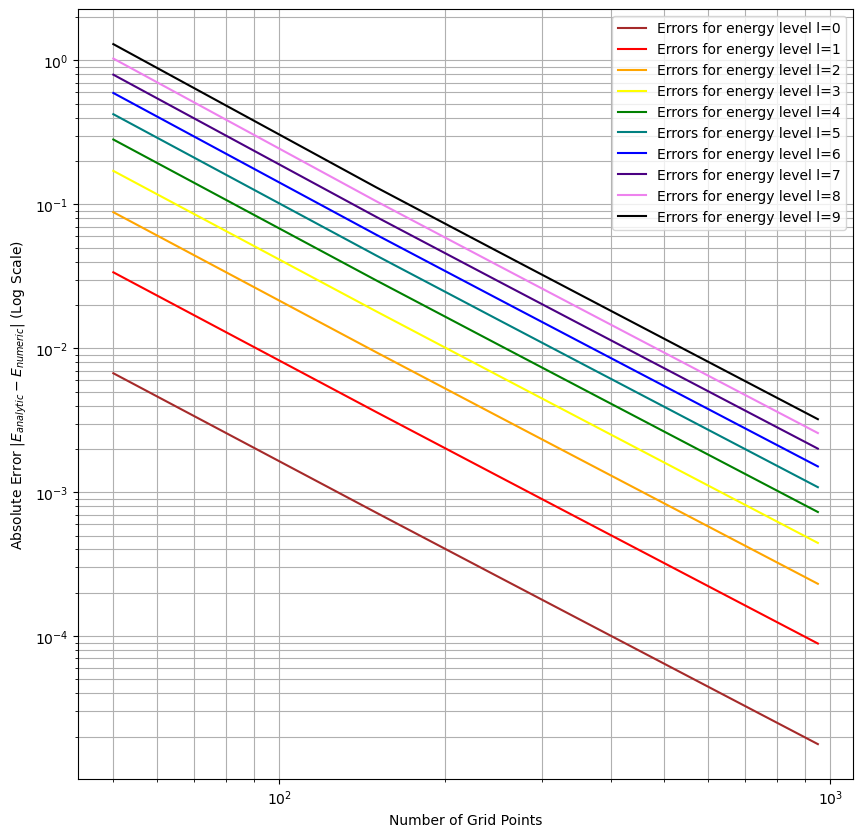

In [5]:
# Defining N range to compute error over
test_n = np.arange(50, 1000, 100)
l_values = np.arange(0, 10, 1) # Defining the number of levels
errors = {l: [] for l in l_values} # Creating a dictionary for error values
colours = ['brown', 'red', 'orange', 'yellow', 'green', 'teal', 'blue', 'indigo', 'violet', 'black'] # Colour list for plotting

for n in test_n:
    n_eigs = max(l_values)+1 # Defining number of eigenvalues to compute
    x, dx, energies, eigs = solve_harmonic_oscillator(x_min, x_max, n, n_eigs) # Call solver function
    
    for l in l_values: # Calculate error for each energy
        analytic_E = 2*l+1
        numeric_E = energies[l]
        err = abs(analytic_E - numeric_E)
        errors[l].append(err) # Add error to dictionary at that energy's index

plt.figure(figsize=(10,10))

for l in l_values:
    plt.plot(test_n, errors[l], label=f'Errors for energy level l={l}', color=colours[l]) # Plot all energy level errors


plt.xlabel('Number of Grid Points')
plt.ylabel('Absolute Error $|E_{analytic} - E_{numeric}|$ (Log Scale)')
plt.yscale('log') # Set log axes
plt.xscale('log')
plt.legend(loc=1)
plt.grid(visible=True, which='both')

## Error analysis for problem 2 ATTEMPT

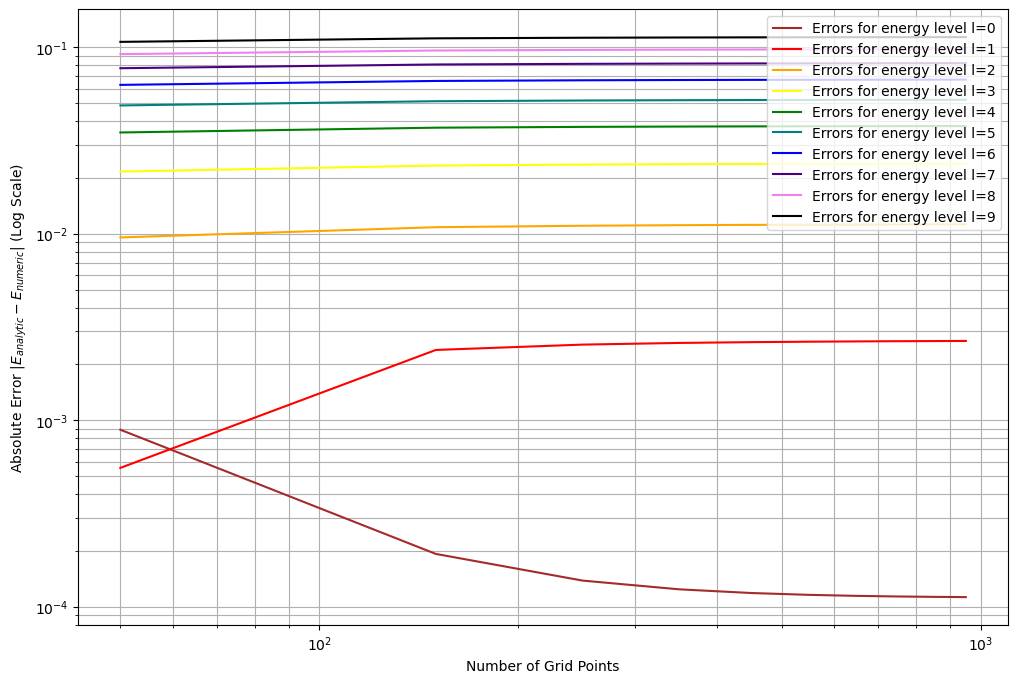

In [7]:

# Define required parameters
r_max = 70.0
n_eig_per_l = 5 # Number of energy levels to calculate for each l

test_n = np.arange(50, 1000, 100)# Defining N range over which to compute error
l_values = np.arange(0, 10, 1) # Defining the number of levels

errors = {l: [] for l in l_values} # Dictionary to store errors

colours = ['brown', 'red', 'orange', 'yellow', 'green', 'teal', 'blue', 'indigo', 'violet', 'black'] # Colour list for plotting



for N_grid in test_n: # Loop over the number of grid points
    
    for l_val in l_values: # Loop over the angular momentum
        r, dr, energies, eigs = solve_hydrogen_radial(r_max, N_grid, l_val, n_eig_per_l) # Call solver function
        
        for i in range(len(energies)): # Loop over the calculated energy levels for this l
            n = i + l_val + 1 # Principal quantum number: n = n_radial + l + 1, where i is n_radial
            analytic_E = -1.0 / (n**2) # Analytic energy calculation
            numeric_E = energies[i] # The i-th energy eigenvalue for this l
            
            err = abs(analytic_E - numeric_E) # Calculate and store error
                
        errors[l_val].append(err)


plt.figure(figsize=(12,8))

for l in l_values:
    plt.plot(test_n, errors[l], label=f'Errors for energy level l={l}', color=colours[l])

plt.xlabel('Number of Grid Points')
plt.ylabel('Absolute Error $|E_{analytic} - E_{numeric}|$ (Log Scale)')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc=1)
plt.grid(visible=True, which='both')
plt.show()